# Common-format grids for every unit in the raw water_scans

Loads every diffuser/collimator unit's raw `.out` scan (not the curated `LightInjectors.json`
subset) from `/bundle/data/T2K/users/nfost94/water_scans`, and builds a native-resolution
`(axis1, axis2, intensity)` grid for each -- `axis1=goalTheta`, `axis2=goalPhi`, both raw and
unmodified, identical loading code for every file regardless of device type. No `theta0`
offset, no folding, no Cartesian conversion here -- those are all analysis-time choices
(recentering on the boresight, projecting to a comparable frame) that belong in the notebook
that uses the data, not baked into storage, so they can be revised without regenerating this
directory. The only reduction happening here is binning genuine exact-duplicate `(theta, phi)`
readings (e.g. repeat measurements at the same commanded position) via `np.add.at`, which is
device-agnostic too.

Every scan gets its own profile, keyed by its own `SampleID` (e.g. `WarwickCol_C64_365nm` and
`WarwickCol_C64_repeated_meas_0` are kept as separate profiles, not collapsed into one
`WarwickCol_C64`) -- no file is dropped or treated as superseding another here.

Two stages, same separation as before: parse + classify (raw-data concern), then build the
common grid (device-agnostic, just consumes theta/phi/intensity).

In [1]:
import re
from io import StringIO
from pathlib import Path
import numpy as np
import pandas as pd

DATA_DIR = Path('/bundle/data/T2K/users/nfost94/water_scans')
OUT_DIR = Path('common_profiles')
OUT_DIR.mkdir(exist_ok=True)

RAW_COLS = ['ts', 'tag', 'iPos', 'goalTheta', 'actualTheta', 'goalPhi', 'actualPhi',
            'op1Power', 'op1PowerSD', 'op1Temp', 'op2Power', 'op2PowerSD', 'op2Temp']


## Stage 1 -- parse and classify every scan (same as `water_scan_profiles.ipynb`)

In [2]:
def load_scan(path):
    """Return (meta dict, data DataFrame) for one .out file."""
    lines = Path(path).read_text().splitlines(keepends=True)
    header_lines = [l for l in lines if l.startswith('%')]
    data_lines = [l for l in lines if not l.startswith('%')]
    meta = {}
    for l in header_lines:
        l = l.lstrip('%').strip()
        if ':' in l:
            key, _, val = l.partition(':')
            meta[key.strip()] = val.strip()
    df = pd.read_csv(StringIO(''.join(data_lines)), header=None)
    df.columns = RAW_COLS[:df.shape[1]]
    df['ts'] = pd.to_datetime(df['ts'])
    return meta, df


UNIT_RE = re.compile(r'Warwick(Col_C\d+|T\d+|DA\d+)')

def sample_id_of(path):
    meta, _ = load_scan(path)
    return meta.get('SampleID', Path(path).stem)

def classify(sample_id):
    if re.search(r'Col_C\d+', sample_id):
        return 'collimator'
    if re.search(r'Warwick(T|DA)\d+', sample_id):
        return 'diffuser'
    return 'other'  # e.g. WarwickWA00_bentback -- excluded below

def unit_id(sample_id):
    m = UNIT_RE.search(sample_id)
    return f'Warwick{m.group(1)}' if m else sample_id


files = sorted(DATA_DIR.glob('*.out'))
manifest = pd.DataFrame({'path': files})
manifest['sample_id'] = manifest['path'].map(sample_id_of)
manifest['device_type'] = manifest['sample_id'].map(classify)
manifest['unit_id'] = manifest['sample_id'].map(unit_id)  # kept for reference, not used to dedupe
manifest = manifest[manifest.device_type != 'other'].sort_values(['device_type', 'sample_id']).reset_index(drop=True)

# every scan gets its own profile, keyed by its own sample_id (e.g. 'WarwickCol_C64_365nm',
# 'WarwickCol_C64_repeated_meas_0', ... all kept separately, not collapsed to one per unit)
print(manifest.device_type.value_counts())
print(f'{len(manifest)} scans, {manifest.unit_id.nunique()} distinct units (some units have multiple scans)')


device_type
collimator    77
diffuser      52
Name: count, dtype: int64
129 scans, 121 distinct units (some units have multiple scans)


## Stage 2 -- build the common-format grid per unit

Raw `goalTheta`/`goalPhi` binned as-is, same code for every unit regardless of device class.

In [3]:
def native_grid(theta_deg, phi_deg, intensity):
    """Native-resolution (axis1, axis2, intensity) grid from raw, unmodified theta/phi --
    no offset, no fold, no transform. np.add.at bins and averages any genuine exact-duplicate
    (theta, phi) reading (e.g. a repeat measurement at the same commanded position); with no
    offset/fold applied there's no theta0+d/theta0-d collision to worry about here.
    """
    theta_deg = np.asarray(theta_deg, dtype=float); phi_deg = np.asarray(phi_deg, dtype=float)
    intensity = np.asarray(intensity, dtype=float)
    axis1 = np.round(theta_deg, 6)
    axis2 = np.round(phi_deg, 6)
    axis1_vals = np.array(sorted(set(axis1))); axis2_vals = np.array(sorted(set(axis2)))
    sums = np.zeros((axis2_vals.size, axis1_vals.size)); counts = np.zeros_like(sums)
    i1 = np.searchsorted(axis1_vals, axis1); i2 = np.searchsorted(axis2_vals, axis2)
    np.add.at(sums, (i2, i1), intensity)
    np.add.at(counts, (i2, i1), 1)
    grid = np.divide(sums, counts, out=np.zeros_like(sums), where=counts > 0)
    return axis1_vals, axis2_vals, grid


built, failed = [], []
for row in manifest.itertuples():
    try:
        _, df = load_scan(row.path)
        grid_df = df[df.tag != 9]  # exclude the collimator's periodic drift-monitor rows
        axis1_vals, axis2_vals, grid = native_grid(
            grid_df['goalTheta'], grid_df['goalPhi'], grid_df['op1Power'],
        )
        out_path = OUT_DIR / f'{row.sample_id}.npz'
        np.savez(out_path, axis1_vals=axis1_vals, axis2_vals=axis2_vals, grid=grid,
                 device_type=row.device_type)
        built.append(row.sample_id)
    except Exception as e:
        failed.append((row.sample_id, str(e)))

print(f'{len(built)} common-format grids written to {OUT_DIR}/, {len(failed)} failed')
for name, err in failed:
    print(f'  FAILED {name}: {err}')

129 common-format grids written to common_profiles/, 0 failed


## Sanity check: load a couple back and look at them

Raw `goalTheta` vs `goalPhi`, unmodified, plotted the same way for both -- the collimator
shows a tight square patch around (90, 0), the diffuser a full-height band (expected: its
`goalPhi` genuinely spans a full 0-360 roll while `goalTheta` covers most of 0-180, so a
circularly-symmetric source looks like a band in these raw, non-recentered axes -- turning it
into a circle is the analysis-time recentering step, not something to bake in here).

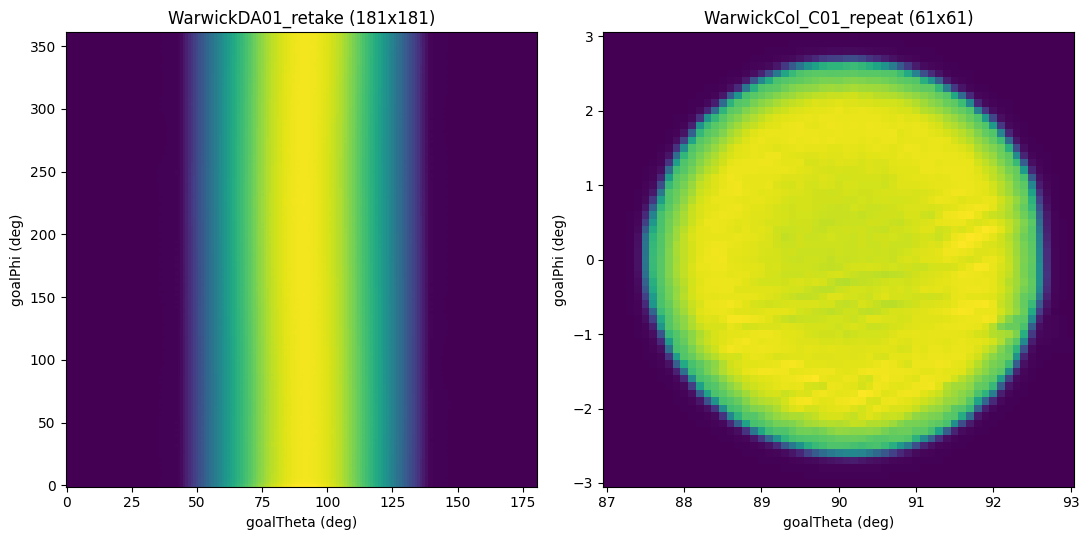

In [4]:
import matplotlib.pyplot as plt

def edges_from_centers(vals):
    dv = np.diff(vals)
    return np.concatenate([[vals[0] - dv[0] / 2], vals[:-1] + dv / 2, [vals[-1] + dv[-1] / 2]])


def plot_common_profile(ax, sample_id):
    d = np.load(OUT_DIR / f'{sample_id}.npz')
    a1, a2, grid = d['axis1_vals'], d['axis2_vals'], d['grid']
    grid = grid / grid.max()
    ax.pcolormesh(edges_from_centers(a1), edges_from_centers(a2), grid, cmap='viridis', vmin=0, vmax=1)
    ax.set_xlabel('goalTheta (deg)'); ax.set_ylabel('goalPhi (deg)')
    ax.set_title(f'{sample_id} ({a1.size}x{a2.size})')


fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
plot_common_profile(axes[0], built[[b.startswith('WarwickT') or b.startswith('WarwickDA') for b in built].index(True)])
plot_common_profile(axes[1], built[[b.startswith('WarwickCol') for b in built].index(True)])
fig.tight_layout(); plt.show()